In [1]:
import pandas as pd
import numpy as np
import random
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

In [3]:
data_2022= pd.read_csv('../data/processed_22.csv')
data_2023 = pd.read_csv('../data/processed_23.csv')

data_2024 = pd.read_csv('../data/processed_24.csv')
data_2025 = pd.read_csv('../data/processed_25.csv')
total = pd.concat([data_2022, data_2023, data_2024, data_2025], ignore_index=True)  

In [4]:
total = total.sort_values('date').reset_index(drop=True)
total['date'] = pd.to_datetime(total['date'])
total = total.set_index('date')

split_index = int(len(total) * 0.75)
train = total.iloc[:split_index]
test = total.iloc[split_index:]


In [5]:
y_train = train['Lpoly_expected_ml']
y_test = test['Lpoly_expected_ml']


In [6]:
bare_baseline = y_train.iloc[-1]
baseline_preds = np.repeat(bare_baseline, len(y_test))

In [9]:
auto_model = auto_arima(y_train, seasonal=False, stepwise=True,
                        information_criterion='aic', trace=True)
optimal_order = auto_model.order
print(f"Optimal ARIMA order: {optimal_order}")
model = ARIMA(y_train, order=optimal_order)
model_fit = model.fit()
forecast_detail = model_fit.get_forecast(steps=len(y_test)) 
conf_int = forecast_detail.conf_int()
forecast = forecast_detail.predicted_mean

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=4237.623, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4768.824, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=4244.144, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4426.379, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=4240.324, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=4242.009, Time=0.06 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=4233.167, Time=0.22 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=4242.985, Time=0.09 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=4197.953, Time=0.35 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=4228.580, Time=0.13 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=4196.693, Time=0.40 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=4226.608, Time=0.25 sec
 ARIMA(5,0,3)(0,0,0)[0]             : AIC=4196.348, Time=0.62 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=4195.627, Time=0.49 sec
 ARIMA(3,0,3)(0,0,0)[0]          

In [10]:
#to line up dates 
forecast.index = y_test.index
conf_int.index = y_test.index

In [11]:
print(y_test.shape)
print(forecast.shape)
print(conf_int.shape)

(202,)
(202,)
(202, 2)


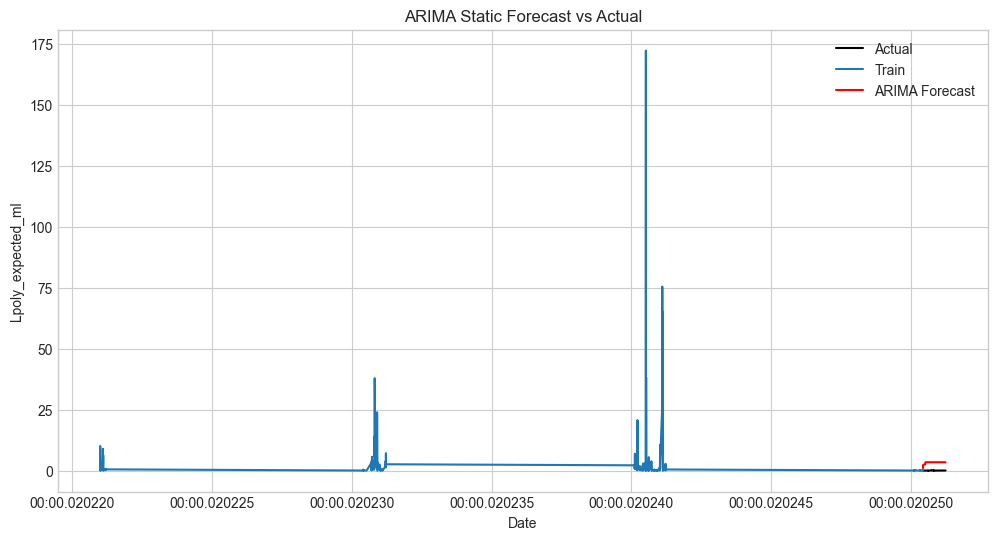

In [54]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_train.index, y_train, label='Train')

plt.plot(y_test.index, forecast, label='ARIMA Forecast', color='red')

plt.title('ARIMA Static Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend()
plt.show()

In [37]:

rmse = np.sqrt(mean_squared_error(y_test, forecast))
mae = mean_absolute_error(y_test, forecast)

print("RMSE: test", rmse)
print("MAE: test", mae)

RMSE: test 3.3715052871028672
MAE: test 3.36187025801101


In [38]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.165063164298931
p-value: 1.0356947479198967e-05


In [47]:
result_diff = adfuller(y_train.diff().dropna())
print("Differenced p-value:", result_diff[1])

Differenced p-value: 3.3495761502261764e-24


In [43]:
#rolling forecast 
history = [x for x in y_train]
predictions = list()
# walk-forward validation
for t in range(len(y_test)):
	model = ARIMA(history, order=optimal_order)
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = y_test.iloc[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))


predicted=1.025591, expected=0.000928
predicted=0.787366, expected=0.000402
predicted=0.791486, expected=0.002657
predicted=0.866774, expected=0.001794
predicted=0.806344, expected=0.008106
predicted=0.772981, expected=0.009292
predicted=0.862827, expected=0.005529
predicted=0.796014, expected=0.001746
predicted=0.771764, expected=0.003466
predicted=0.846937, expected=0.001238
predicted=0.788720, expected=0.002505
predicted=0.773895, expected=0.000923
predicted=0.833997, expected=0.002620
predicted=0.785362, expected=0.030539
predicted=0.799435, expected=0.016873
predicted=0.834397, expected=0.002762
predicted=0.773828, expected=0.005123
predicted=0.783018, expected=0.022086
predicted=0.836566, expected=0.006149
predicted=0.770597, expected=0.005463
predicted=0.777510, expected=0.015202
predicted=0.825883, expected=0.006713
predicted=0.769674, expected=0.020840
predicted=0.786204, expected=0.028569
predicted=0.829451, expected=0.022086
predicted=0.776023, expected=0.006359
predicted=0.

In [45]:
rmse_rolling = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE: rolling forecast", rmse_rolling)

RMSE: rolling forecast 0.6918322688811314


In [53]:
history = []
rolling_preds = []

for t in range(len(total)):
    if t < 5:
        rolling_preds.append(np.nan)
        history.append(total['Lpoly_expected_ml'].iloc[t])
        continue
        
    model = ARIMA(history, order=optimal_order)
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    
    rolling_preds.append(yhat)
    history.append(total['Lpoly_expected_ml'].iloc[t])

walk_forward_val = pd.Series(rolling_preds, index=total.index)

In [55]:
walk_forward_val.index

DatetimeIndex(['1970-01-01 00:00:00.020221005',
               '1970-01-01 00:00:00.020221006',
               '1970-01-01 00:00:00.020221007',
               '1970-01-01 00:00:00.020221008',
               '1970-01-01 00:00:00.020221009',
               '1970-01-01 00:00:00.020221010',
               '1970-01-01 00:00:00.020221011',
               '1970-01-01 00:00:00.020221013',
               '1970-01-01 00:00:00.020221014',
               '1970-01-01 00:00:00.020221019',
               ...
               '1970-01-01 00:00:00.020251222',
               '1970-01-01 00:00:00.020251223',
               '1970-01-01 00:00:00.020251224',
               '1970-01-01 00:00:00.020251225',
               '1970-01-01 00:00:00.020251226',
               '1970-01-01 00:00:00.020251227',
               '1970-01-01 00:00:00.020251228',
               '1970-01-01 00:00:00.020251229',
               '1970-01-01 00:00:00.020251230',
               '1970-01-01 00:00:00.020251231'],
              dtype=

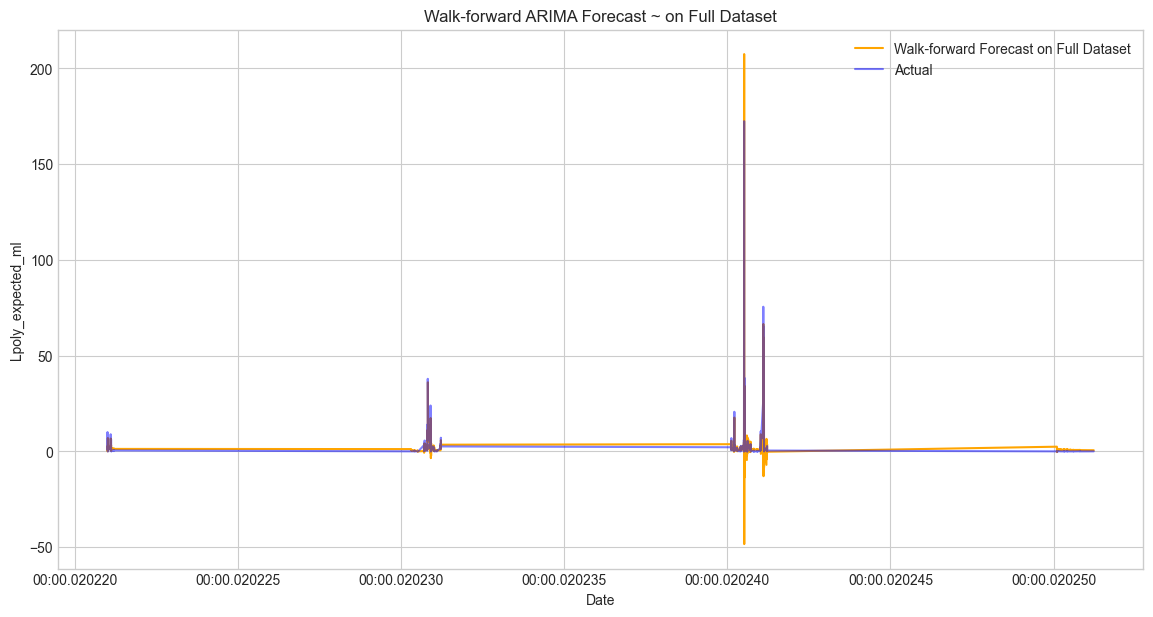

In [68]:
plt.figure(figsize=(14,7))

plt.plot(walk_forward_val.index[1:], walk_forward_val[1:], label='Walk-forward Forecast on Full Dataset', color='orange')
plt.plot(total.index, total['Lpoly_expected_ml'], label='Actual', color='blue',alpha=0.5)
plt.title('Walk-forward ARIMA Forecast ~ on Full Dataset')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend()
plt.show()

In [58]:
history_1 = list(y_train)  # start with all training data
rolling_preds = []

for t in range(len(y_test)):
    model = ARIMA(history_1, order=optimal_order)
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    
    rolling_preds.append(yhat)
    history_1.append(y_test.iloc[t])  # add true value each step

rolling_series = pd.Series(rolling_preds, index=y_test.index)

rolling_rmse = np.sqrt(mean_squared_error(y_test, rolling_series))
rolling_mae = mean_absolute_error(y_test, rolling_series)
print(f"Rolling RMSE: {rolling_rmse:.4f}")
print(f"Rolling MAE:  {rolling_mae:.4f}")




Rolling RMSE: 0.6918
Rolling MAE:  0.6882


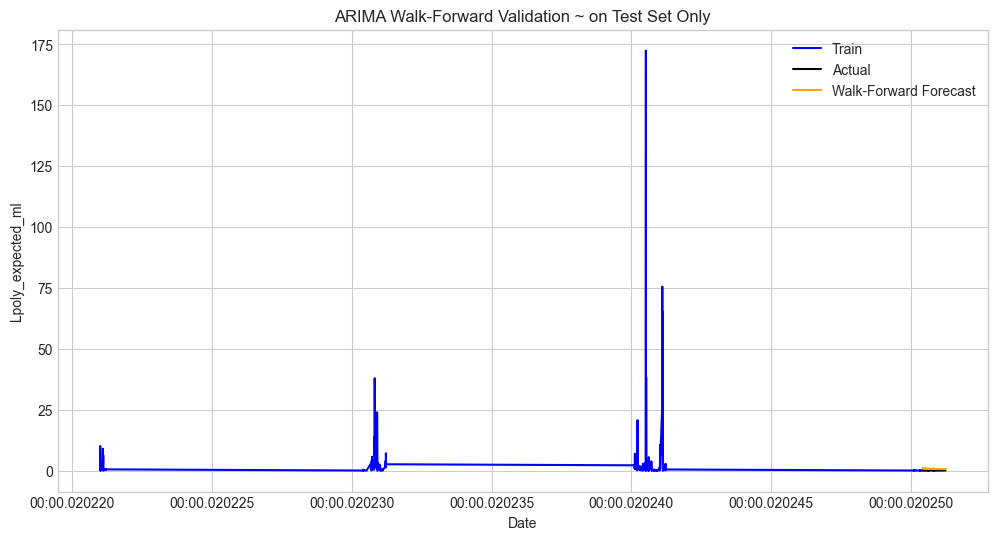

In [60]:
plt.figure(figsize=(12,6))
plt.plot(y_train.index, y_train, label='Train', color='blue')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, rolling_series, label='Walk-Forward Forecast', color='orange')


plt.title('ARIMA Walk-Forward Validation ~ on Test Set Only')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend()
plt.show()

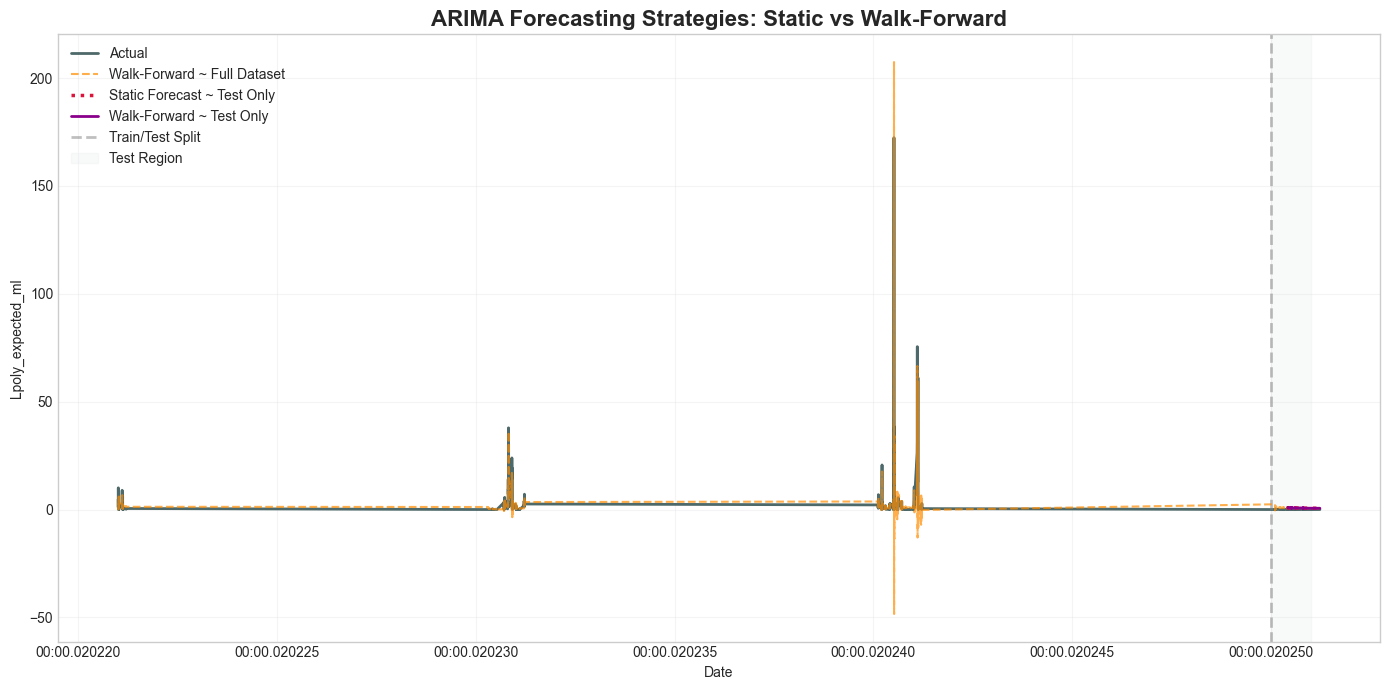

In [ ]:
import matplotlib.pyplot as plt

split_date = total.index[split_index]

plt.figure(figsize=(14,7))
plt.style.use('seaborn-v0_8-whitegrid')

# Actual
plt.plot(total.index, total['Lpoly_expected_ml'],
         label='Actual', color='#2F4F4F',
         linestyle='-', alpha=0.85, linewidth=2, zorder=2)

# Walk-forward on full dataset 
plt.plot(walk_forward_val.index, walk_forward_val,
         label='Walk-Forward ~ Full Dataset', color='#FF8C00',
         linestyle='--', linewidth=1.5, alpha=0.7, zorder=3)

# Static forecast 
plt.plot(pred_series.index, pred_series,
         label='Static Forecast ~ Test Only', color='#DC143C',
         linestyle=':', linewidth=2.5, zorder=4)

# Walk-forward on test set 
plt.plot(y_test.index, rolling_series,
         label='Walk-Forward ~ Test Only', color='#8B008B',
         linestyle='-', linewidth=2, zorder=5)

plt.axvline(x=split_date, color='gray', linestyle='--',
            linewidth=2, alpha=0.5, label='Train/Test Split', zorder=2)

plt.axvspan(split_date, total.index[-1], color='#EAECEE',
            alpha=0.3, label='Test Region', zorder=0)

plt.title('ARIMA Forecasting Strategies: Static vs Walk-Forward', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()